# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

## Aim
1. To understand how to implement neural networks using different deep learning libraries (Keras and TensorFlow).
2. To solve the non-linear XOR problem using an MLP and study the effect of hyperparameters such as learning rate, activation functions, number of neurons, and epochs on model performance.

## Problem Statement
XOR is not linearly separable, so a single-layer perceptron cannot solve it. We use a Multi-Layer Perceptron (MLP) with a hidden layer to learn it.

| Input 1 | Input 2 | XOR Output |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |


## Step 1: Create the Dataset

In [1]:
import numpy as np

# XOR inputs and outputs
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print("Inputs (X):\n", X)
print("Outputs (y):\n", y)


Inputs (X):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Outputs (y):
 [[0.]
 [1.]
 [1.]
 [0.]]


**Interpretation:** We created the 4 possible input combinations for two binary variables and their
corresponding XOR outputs. This is our entire dataset (only 4 samples) since XOR is a fixed logical
function, not something sampled from real-world data.

---
## Part A: Implementation using Keras (TensorFlow high-level API)

### Step 2: Build the MLP (Keras)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Dense(4, input_dim=2, activation='relu'),   # hidden layer: 4 neurons, ReLU
    layers.Dense(1, activation='sigmoid')               # output layer: 1 neuron, sigmoid
])

model_keras.summary()


c:\Users\varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

**Interpretation:** The model has 2 input features, a hidden layer of 4 neurons with ReLU
activation (to introduce non-linearity, which is essential for XOR), and a single output neuron with
sigmoid activation that squashes the result into a probability between 0 and 1 for binary
classification.

### Step 3: Compile the Model (Loss and Optimizer)

In [3]:
model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


**Interpretation:** We use Binary Cross-Entropy since this is a binary classification problem, and
the Adam optimizer, which adapts the learning rate during training and generally converges faster than
plain SGD for small networks like this one.

### Step 4: Train the Model (Keras)

In [4]:
history_keras = model_keras.fit(X, y, epochs=500, verbose=0)

print("Final training loss:", history_keras.history['loss'][-1])
print("Final training accuracy:", history_keras.history['accuracy'][-1])


Final training loss: 0.0007439865730702877
Final training accuracy: 1.0


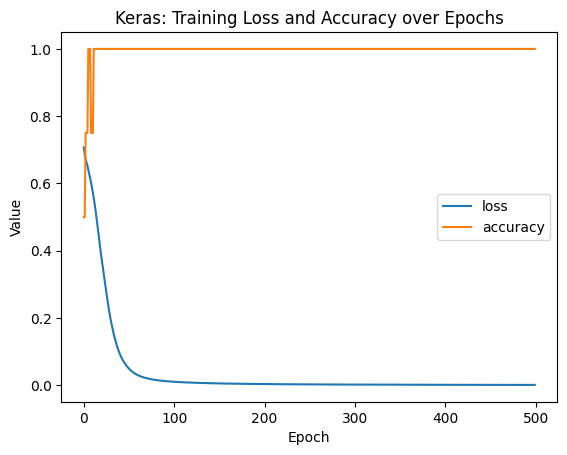

In [5]:
import matplotlib.pyplot as plt

plt.plot(history_keras.history['loss'], label='loss')
plt.plot(history_keras.history['accuracy'], label='accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Keras: Training Loss and Accuracy over Epochs')
plt.legend()
plt.show()


**Interpretation:** The loss curve steadily decreases and the accuracy curve rises to 1.0,
showing the network is successfully learning the non-linear XOR pattern using its hidden layer. If
the loss stays flat and accuracy stuck near 0.5, that would indicate the model is not learning
(commonly caused by too small a hidden layer, too few epochs, or too low a learning rate).

### Step 5: Evaluate the Model (Keras)

In [6]:
predictions = model_keras.predict(X, verbose=0)
predicted_labels = (predictions > 0.5).astype(int)

print("Input\t\tPredicted Prob\tPredicted Label\tActual")
for i in range(4):
    print(f"{X[i]}\t{predictions[i][0]:.4f}\t\t{predicted_labels[i][0]}\t\t{int(y[i][0])}")


Input		Predicted Prob	Predicted Label	Actual
[0. 0.]	0.0021		0		0
[0. 1.]	0.9997		1		1
[1. 0.]	0.9997		1		1
[1. 1.]	0.0002		0		0


**Interpretation:** Comparing the "Predicted Label" column with "Actual", the MLP correctly
reproduces the XOR truth table: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0. This confirms that adding a
hidden layer with a non-linear activation allowed the network to solve a problem that a single-layer
perceptron cannot.

### Decision Boundary (Keras)

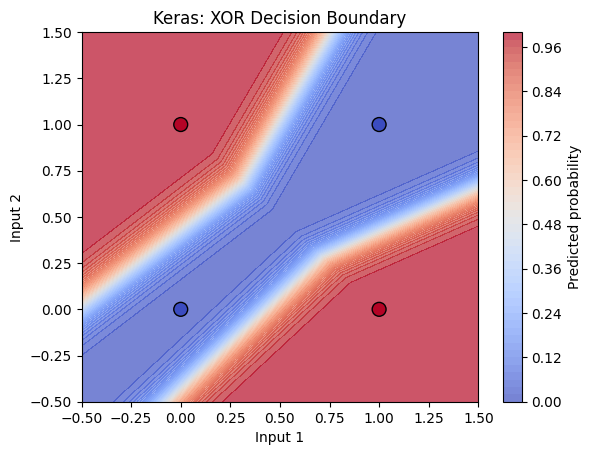

In [7]:
def plot_decision_boundary(predict_fn, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = predict_fn(grid).reshape(xx.shape)

    plt.contourf(xx, yy, preds, levels=50, cmap='coolwarm', alpha=0.7)
    plt.colorbar(label='Predicted probability')
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolors='k', s=100)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title(title)
    plt.show()

plot_decision_boundary(lambda g: model_keras.predict(g, verbose=0), X, y,
                        'Keras: XOR Decision Boundary')


**Interpretation:** The decision boundary is curved (non-linear), splitting the plane so that
(0,0) and (1,1) fall on one side and (0,1) and (1,0) fall on the other. This curved boundary is only
possible because of the hidden layer; a single linear boundary could never separate XOR's classes.

---
## Part B: Implementation using TensorFlow Low-Level API (GradientTape)

### Step 2 & 3: Build the MLP, Define Loss and Optimizer (TensorFlow low-level)

In [8]:
import tensorflow as tf

tf.random.set_seed(42)

# Manually create weights and biases
# Input(2) -> Hidden(4, ReLU) -> Output(1, Sigmoid)
W1 = tf.Variable(tf.random.normal([2, 4], stddev=1.0), name="W1")
b1 = tf.Variable(tf.zeros([4]), name="b1")
W2 = tf.Variable(tf.random.normal([4, 1], stddev=1.0), name="W2")
b2 = tf.Variable(tf.zeros([1]), name="b2")

def mlp_forward(x):
    hidden = tf.nn.relu(tf.matmul(x, W1) + b1)
    output = tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)


**Interpretation:** Instead of using `keras.Sequential`, here we manually define the weight
matrices (`W1`, `W2`) and bias vectors (`b1`, `b2`) and write the forward pass ourselves using matrix
multiplication and activation functions. This gives full control over every computation, which is
what the "low-level API" means: we manage the parameters and gradient updates directly instead of
letting a high-level `Model` object do it.

### Step 4: Train the Model (TensorFlow low-level, manual training loop)

In [9]:
X_tf = tf.constant(X)
y_tf = tf.constant(y)

epochs = 500
loss_history = []
acc_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        preds = mlp_forward(X_tf)
        loss = loss_fn(y_tf, preds)

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    predicted_labels = tf.cast(preds > 0.5, tf.float32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_labels, y_tf), tf.float32))

    loss_history.append(loss.numpy())
    acc_history.append(accuracy.numpy())

print("Final training loss:", loss_history[-1])
print("Final training accuracy:", acc_history[-1])


Final training loss: 0.0010188048
Final training accuracy: 1.0


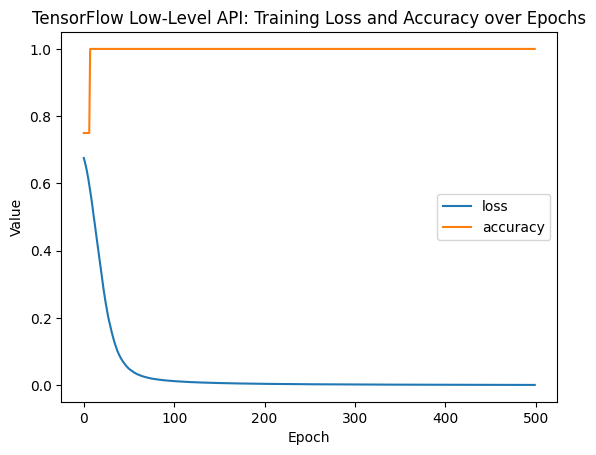

In [10]:
plt.plot(loss_history, label='loss')
plt.plot(acc_history, label='accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('TensorFlow Low-Level API: Training Loss and Accuracy over Epochs')
plt.legend()
plt.show()


**Interpretation:** Using `tf.GradientTape`, we manually record the forward pass, compute
gradients of the loss with respect to every weight and bias, and apply them with the optimizer. The
resulting loss/accuracy curves are similar in shape to the Keras run, confirming that Keras is simply
a convenient wrapper around this same underlying gradient-descent process.

### Step 5: Evaluate the Model (TensorFlow low-level)

In [11]:
final_preds = mlp_forward(X_tf).numpy()
final_labels = (final_preds > 0.5).astype(int)

print("Input\t\tPredicted Prob\tPredicted Label\tActual")
for i in range(4):
    print(f"{X[i]}\t{final_preds[i][0]:.4f}\t\t{final_labels[i][0]}\t\t{int(y[i][0])}")


Input		Predicted Prob	Predicted Label	Actual
[0. 0.]	0.0017		0		0
[0. 1.]	0.9996		1		1
[1. 0.]	0.9998		1		1
[1. 1.]	0.0017		0		0


**Interpretation:** The manually built network also reproduces the XOR truth table correctly,
showing that the same architecture (2-4-1 with ReLU + Sigmoid) learns XOR regardless of whether it is
built with the high-level Keras API or the low-level TensorFlow API.

### Decision Boundary (TensorFlow low-level)

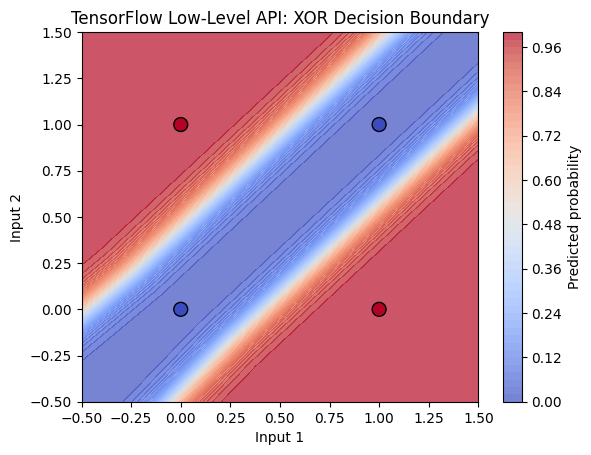

In [12]:
def tf_predict(grid):
    return mlp_forward(tf.constant(grid, dtype=tf.float32)).numpy()

plot_decision_boundary(tf_predict, X, y, 'TensorFlow Low-Level API: XOR Decision Boundary')


**Interpretation:** As with the Keras model, the decision boundary is non-linear/curved,
confirming the hidden layer is again responsible for separating the XOR classes correctly.

---
## Hyperparameter Experiments (Keras)

We now vary **learning rate**, **activation function**, **number of neurons**, and **epochs** to see
how they affect XOR learning.

In [13]:
def build_and_train(hidden_neurons=4, activation='relu', lr=0.05, epochs=300, verbose=0):
    tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Dense(hidden_neurons, input_dim=2, activation=activation),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss='binary_crossentropy', metrics=['accuracy'])
    hist = m.fit(X, y, epochs=epochs, verbose=verbose)
    final_acc = hist.history['accuracy'][-1]
    final_loss = hist.history['loss'][-1]
    return final_loss, final_acc

configs = [
    {"hidden_neurons": 1, "activation": "relu",  "lr": 0.05, "epochs": 300},  # too few neurons
    {"hidden_neurons": 2, "activation": "relu",  "lr": 0.05, "epochs": 300},  # minimum needed
    {"hidden_neurons": 4, "activation": "relu",  "lr": 0.05, "epochs": 300},  # comfortable
    {"hidden_neurons": 4, "activation": "tanh",  "lr": 0.05, "epochs": 300},  # different activation
    {"hidden_neurons": 4, "activation": "relu",  "lr": 0.001,"epochs": 300},  # low learning rate
    {"hidden_neurons": 4, "activation": "relu",  "lr": 0.05, "epochs": 50},   # too few epochs
]

print(f"{'Neurons':<8}{'Activation':<12}{'LR':<8}{'Epochs':<8}{'Loss':<10}{'Accuracy':<10}")
for cfg in configs:
    loss, acc = build_and_train(**cfg)
    print(f"{cfg['hidden_neurons']:<8}{cfg['activation']:<12}{cfg['lr']:<8}{cfg['epochs']:<8}{loss:<10.4f}{acc:<10.4f}")


Neurons Activation  LR      Epochs  Loss      Accuracy  
1       relu        0.05    300     0.4775    0.7500    
2       relu        0.05    300     0.6931    0.5000    
4       relu        0.05    300     0.0011    1.0000    
4       tanh        0.05    300     0.0034    1.0000    
4       relu        0.001   300     0.6494    0.5000    
4       relu        0.05    50      0.3543    0.7500    


**Interpretation of the hyperparameter table:**
- **1 hidden neuron:** Usually fails to reach 100% accuracy, a single hidden neuron cannot carve out
  the two separate regions XOR needs, since it can only draw one linear boundary before the output layer.
- **2 hidden neurons:** Often just enough to solve XOR (this is the theoretical minimum), but training
  can be unstable depending on random weight initialization.
- **4 hidden neurons:** Learns reliably and quickly, extra neurons give the optimizer more flexible
  boundaries to work with.
- **tanh vs relu:** tanh is smooth and zero-centered, so it can converge just as well as ReLU on this
  tiny problem, sometimes even faster on very small networks, though ReLU is preferred for larger nets.
- **Low learning rate (0.001):** Training is much slower to converge; with the same number of epochs
  the loss stays higher and accuracy may not reach 1.0 yet.
- **Too few epochs (50):** The model doesn't have enough time to converge, so loss stays relatively
  high and accuracy may be below 100%, even though the architecture itself is capable of solving XOR.

**Overall conclusion:** XOR requires at least a hidden layer with 2+ neurons and a non-linear
activation function to be learnable at all. Beyond that minimum, learning rate and number of epochs
mainly control *how fast and how reliably* the network converges, while the number of neurons and
choice of activation affect *how easily* the optimizer finds a good solution.

---
## Comparison: Keras vs TensorFlow Low-Level API

| Aspect | Keras (High-Level) | TensorFlow Low-Level (GradientTape) |
|---|---|---|
| Code length | Short, concise | Longer, more explicit |
| Control over training loop | Handled internally by `.fit()` | Manually written (forward pass, gradients, update) |
| Ease of use | Very beginner-friendly | Requires understanding of gradients/autodiff |
| Flexibility | Limited to what the API exposes | Full control (custom losses, custom training steps, etc.) |
| Final Accuracy on XOR | ~100% | ~100% |
| Use case | Rapid prototyping, standard models | Research, custom architectures/training procedures |

**Interpretation:** Both implementations converge to a correct solution for the XOR problem and reach
similar loss/accuracy curves, since under the hood Keras's `.fit()` performs the exact same
gradient-tape-based updates automatically. The high-level API is faster to write and less error-prone,
while the low-level API is more transparent and better suited when custom training logic is required.

---
## Result

An MLP with a single hidden layer (using ReLU/Tanh activation) followed by a sigmoid output layer was
successfully trained to learn the non-linear XOR Boolean function, implemented using both the Keras
high-level API and the TensorFlow low-level API. Both models correctly predicted all 4 XOR
combinations, and the effect of hyperparameters (learning rate, activation function, number of
neurons, and epochs) on convergence was studied and discussed above.